In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("../Data/cleaned_data_transformed.csv")

In [7]:
data

,price,city,neighbourhood,bedrooms,bathrooms,surface_area,subcategory,latitude,longitude,furnished?,property_mortgaged?,lister_type,facade,price_per_meter_square
0,720000.0,Benghazi,Qar Yunis,3.0,2.0,105.0,Apartment,32.847191,13.125021,False,False,Agent,Eastern,6857.142857
1,725000.0,Benghazi,Al Hawary,3.0,2.0,105.0,Apartment,32.778309,13.264442,False,False,Landlord,Eastern,6904.761905
2,290000.0,Benghazi,Venice,4.0,2.0,155.0,Apartment,32.763538,13.181585,False,False,Agent,Eastern,1870.967742
3,230000.0,Benghazi,Al Sayeda Aesha,4.0,2.0,160.0,Apartment,32.781060,13.078820,False,False,Landlord,Eastern,1437.500000
4,450000.0,Benghazi,Qar Yunis,2.0,1.0,120.0,Apartment,32.829285,13.102837,False,False,Landlord,Eastern,3750.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,250000.0,tripoli,Tareeq Al Mashtal,7.0,5.0,450.0,Villa,32.823380,13.127478,False,False,Agent,Western,555.555556
1967,450000.0,tripoli,Ain Zara,7.0,3.0,350.0,Villa,32.022217,20.033054,False,False,Agent,Western,1285.714286
1968,245000.0,tripoli,Al Jabs,7.0,4.0,560.0,Villa,32.837254,13.011137,False,False,Agent,Western,437.500000
1969,250000.0,tripoli,Al Sabaa,5.0,4.0,300.0,Villa,32.889301,13.185127,False,False,Agent,Western,833.333333


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'surface_area'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'price_per_meter_square'}>, <Axes: >,
        <Axes: >]], dtype=object)

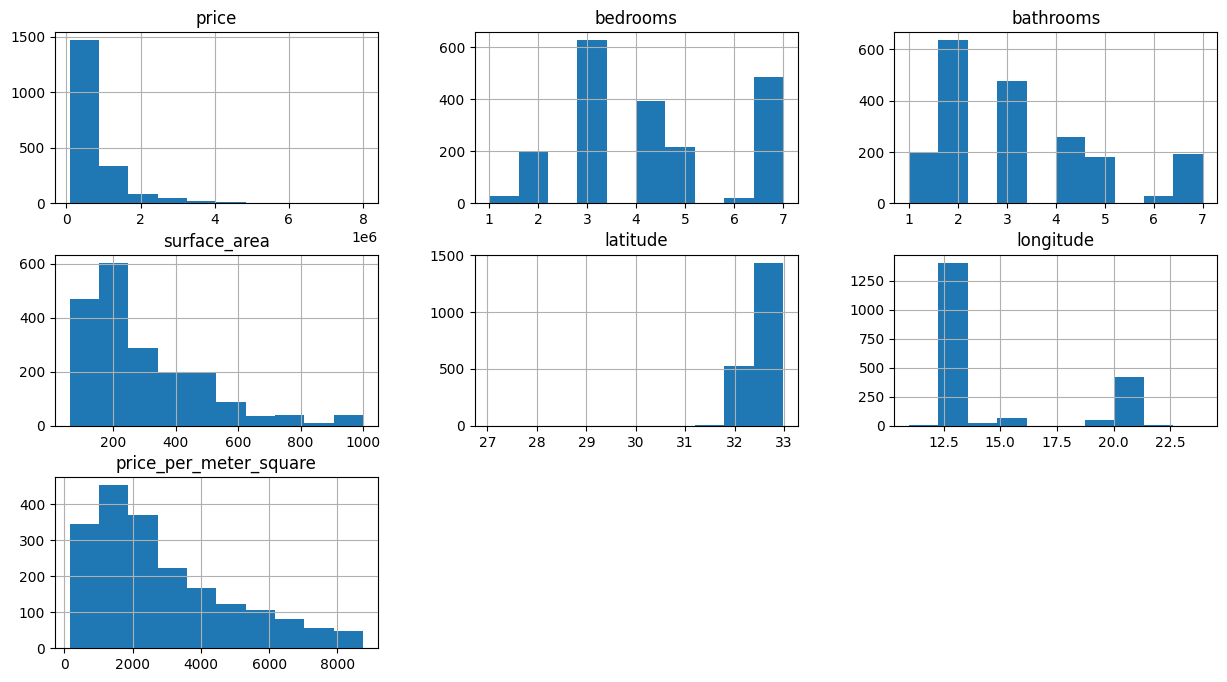

In [4]:
data.hist(figsize=(15,8))

Log Normalising Scewed Data

In [8]:
data['price'] = np.log(data['price'] + 1)
data['surface_area'] = np.log(data['surface_area'] + 1)
data['price_per_meter_square'] = np.log(data['price_per_meter_square'] + 1)

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'surface_area'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'price_per_meter_square'}>, <Axes: >,
        <Axes: >]], dtype=object)

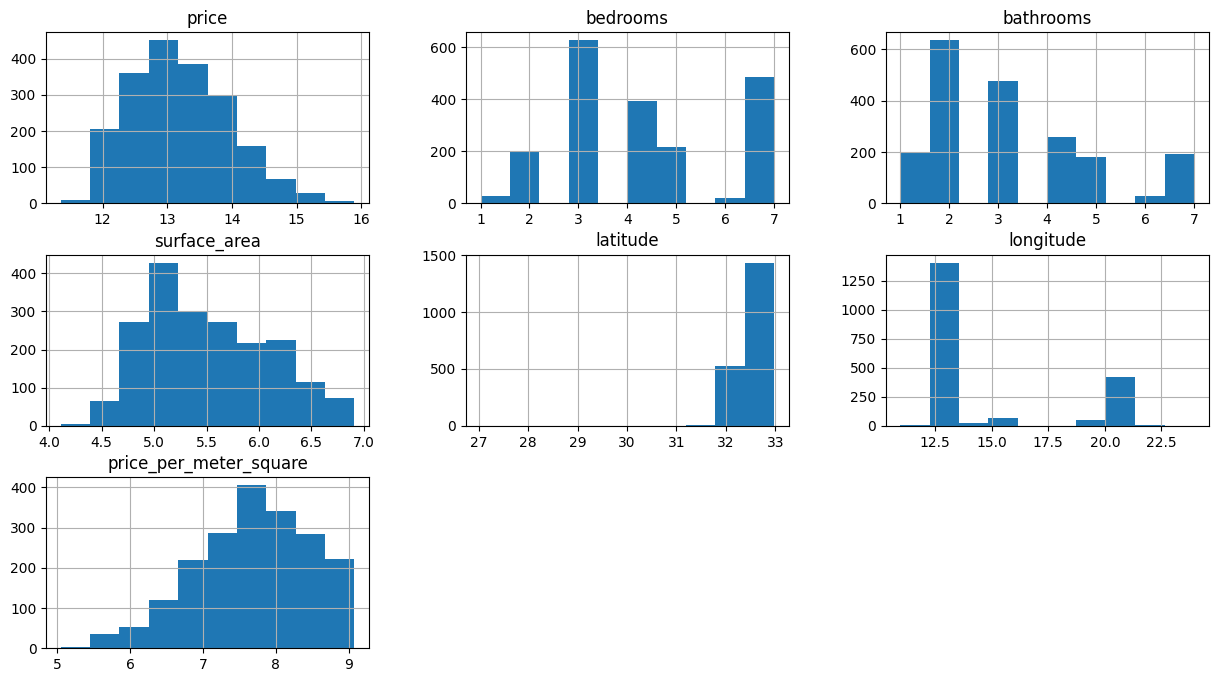

In [9]:
data.hist(figsize=(15,8))

Ecoding String Columns

In [15]:
data = data.join(pd.get_dummies(data.city)).drop(['city'], axis=1)

In [14]:
data = data.join(pd.get_dummies(data.subcategory)).drop(['subcategory'], axis=1)

In [16]:
data = data.join(pd.get_dummies(data.lister_type)).drop(['lister_type'], axis=1)

In [19]:
data = data.join(pd.get_dummies(data.facade)).drop(['facade'], axis=1)

AttributeError: 'DataFrame' object has no attribute 'facade'

In [24]:
data = data.drop(['neighbourhood'], axis=1)

<Axes: >

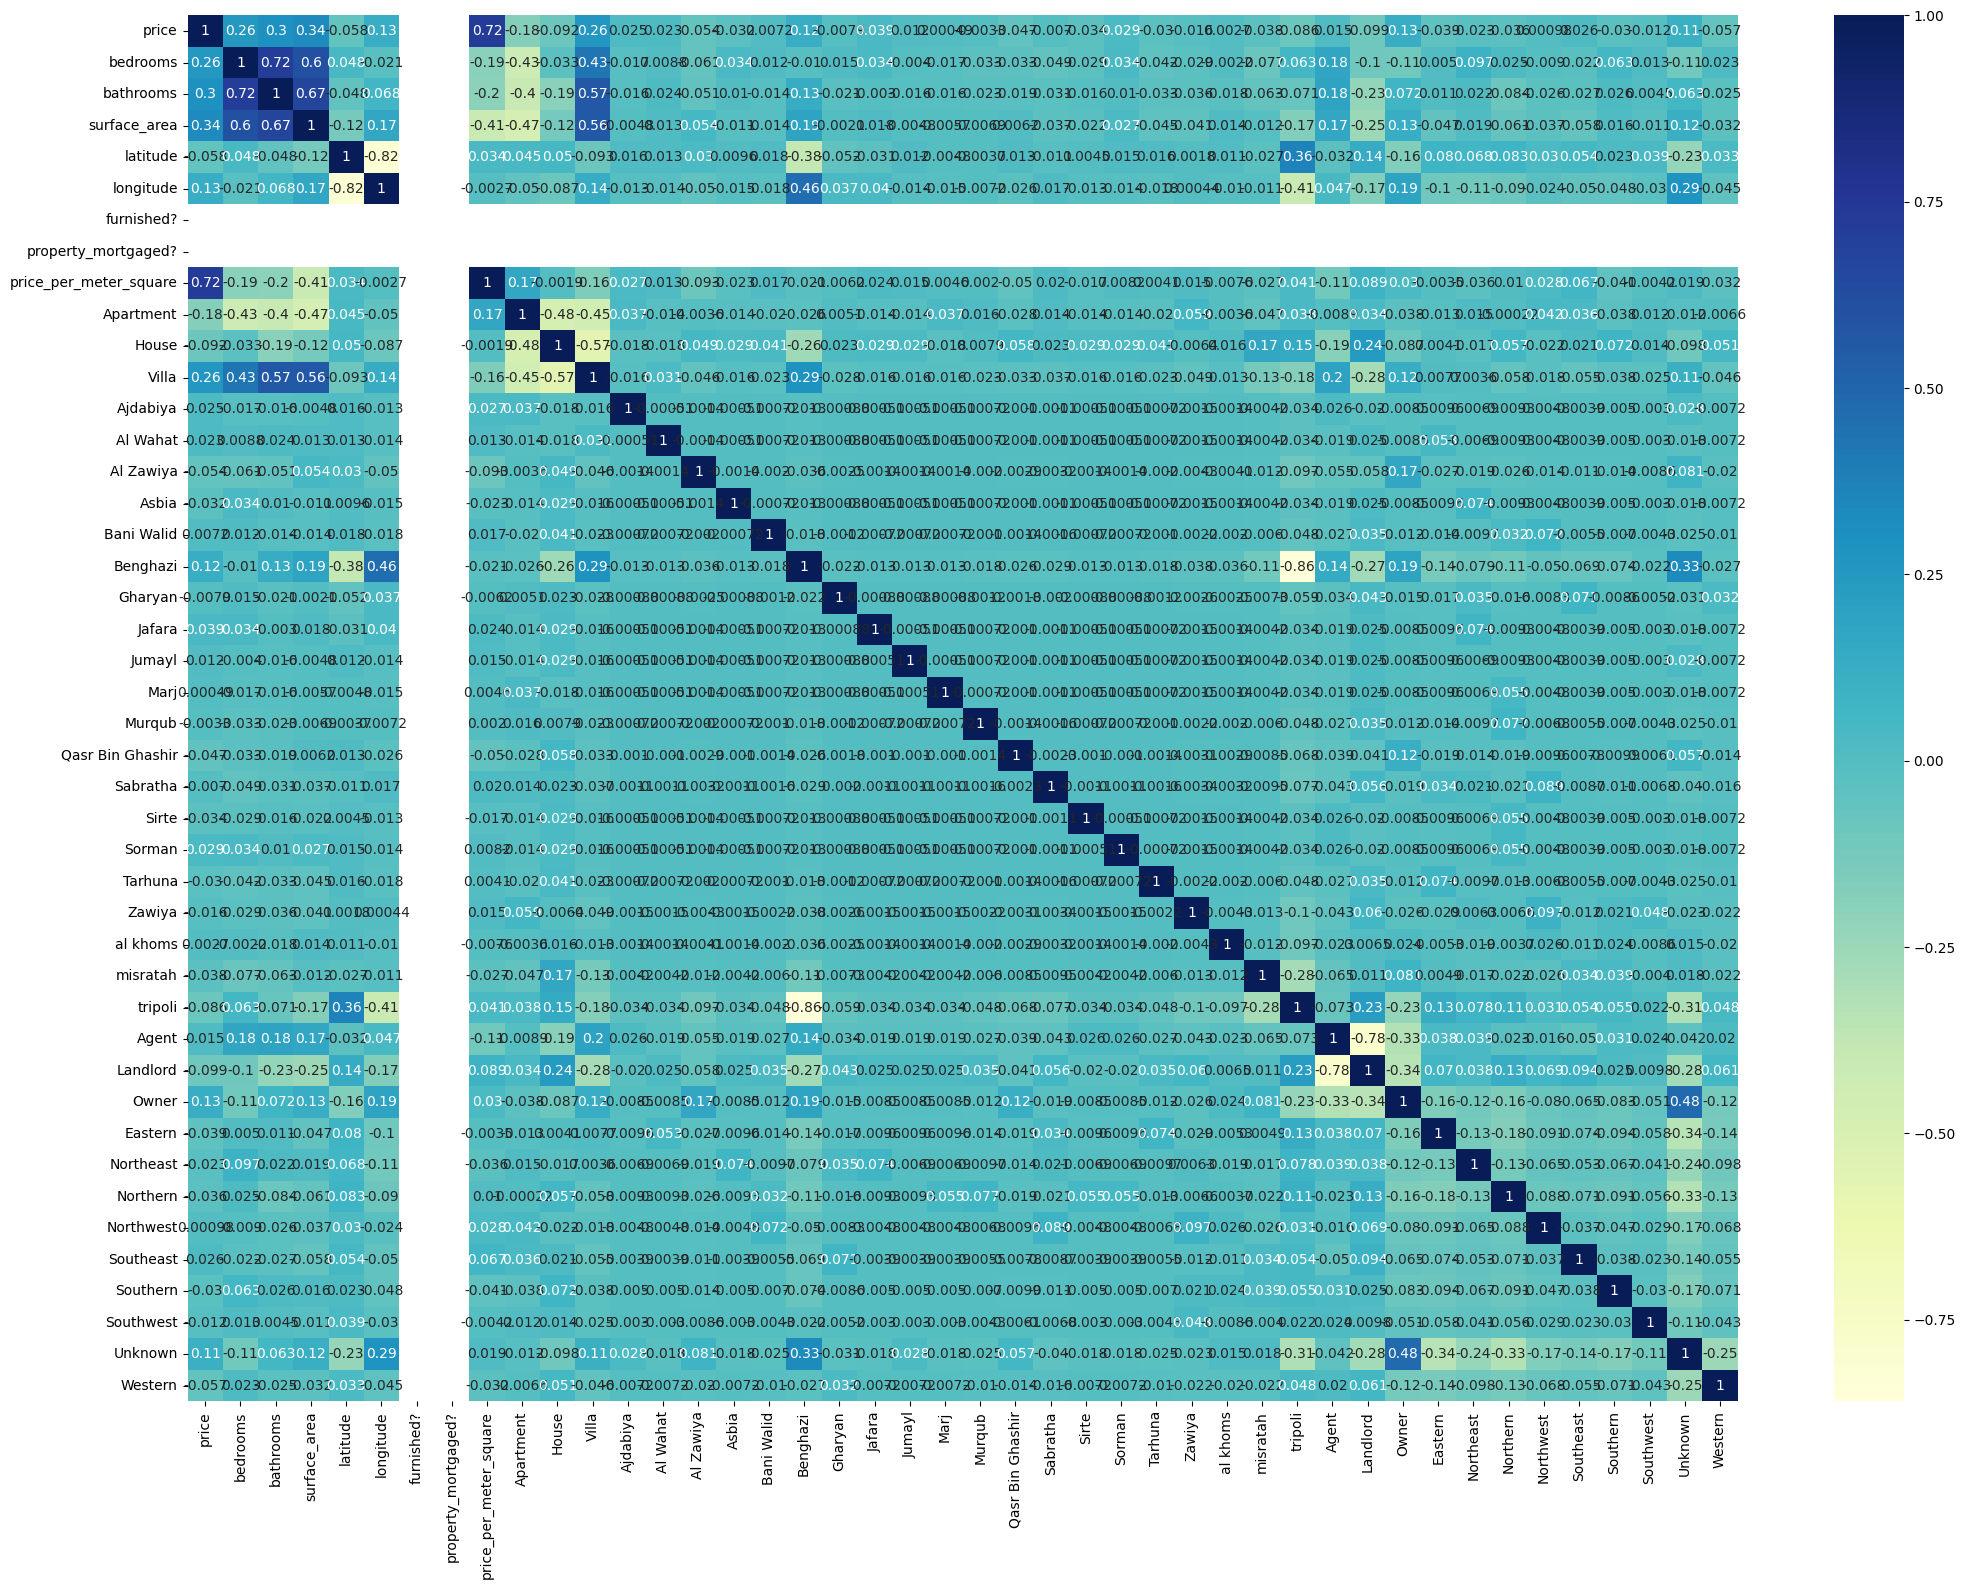

In [27]:
plt.figure(figsize=(25,18))
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")